In [1]:
import pandas as pd
import numpy as np

# 先讀進模擬資料
# data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\embedding_data.csv")

data = pd.read_csv(r"C:\Users\GUO\Desktop\Attention_NN_CYG_SSE\產生模擬資料\raw_data.csv")

cols = data.columns[:-1].to_list() 

whole = data.copy()

data = whole.iloc[0:700,:]

# data[cols] = (data[cols] - data[cols].mean()) / data[cols].std() # 針對變數標準化，後面做softmax的時候，數值才不會爆掉

validation = whole.iloc[700:1000,:]

# validation[cols] = (validation[cols] - validation[cols].mean()) / validation[cols].std()

# print(len(whole))
# print(len(data))
# print(len(validation))
print(data)

     Intercept        X1        X2        X3        X4        X5        X6  \
0          1.0 -1.085631  0.997345  0.282978 -1.506295 -0.578600  1.651437   
1          1.0 -0.678886 -0.094709  1.491390 -0.638902 -0.443982 -0.434351   
2          1.0  0.737369  1.490732 -0.935834  1.175829 -1.253881 -0.637752   
3          1.0 -0.255619 -2.798589 -1.771533 -0.699877  0.927462 -0.173636   
4          1.0 -0.805367 -1.727669 -0.390900  0.573806  0.338589 -0.011830   
..         ...       ...       ...       ...       ...       ...       ...   
695        1.0  0.661237  1.661704  0.146308 -1.440363 -0.337606 -1.264824   
696        1.0  1.362658  1.358218 -0.202482 -0.426890  0.993713 -0.645431   
697        1.0  1.712590 -0.123802 -0.244599 -0.333306  0.132421 -0.274772   
698        1.0  1.056521  1.156889 -0.124842 -1.214387  0.964954  0.877813   
699        1.0 -1.176536  2.077878  0.153977  0.573717 -0.095553  0.461053   

           X7        X8        X9       X10          Y  
0   -2

In [2]:
X = data[cols]

XTX = X.T @ X

y = data["Y"]

# beta
beta = np.linalg.inv(X.T @ X) @ X.T @ y

print("手算:")
print(beta)
print("---------------------------------------------")

# 用套件驗證
import statsmodels.api as sm

X = data[cols]

model = sm.OLS(
    data["Y"],
    X          
)

result = model.fit()

print("套件驗證:")
print(result.params)

手算:
0     1.932738
1     1.984513
2    -1.459544
3     0.522878
4    -0.132968
5     3.017042
6     0.004333
7    -0.049727
8    -0.059095
9    -0.039714
10    0.013323
dtype: float64
---------------------------------------------
套件驗證:
Intercept    1.932738
X1           1.984513
X2          -1.459544
X3           0.522878
X4          -0.132968
X5           3.017042
X6           0.004333
X7          -0.049727
X8          -0.059095
X9          -0.039714
X10          0.013323
dtype: float64


In [3]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score


# ======================
# Split X and Y
# ======================

X_train = data[cols].values
y_train = data["Y"].values

X_test = validation[cols].values
y_test = validation["Y"].values


# ======================
# Ridge model
# ======================

ridge = Ridge(alpha=1.0, fit_intercept=False)

ridge.fit(
    X_train,
    y_train,
)
print("套件算Ridge的係數:")
print(ridge.coef_)
print("---------------------------------------------")

# 手算Ridge
lamda = 1
I = np.eye(
    len(cols)
)
beta_ridge = np.linalg.inv(X_train.T @ X_train + lamda * I) @ X_train.T @ y_train
print("手算Ridge:")
print(beta_ridge)


套件算Ridge的係數:
[ 1.929794    1.98167384 -1.45727846  0.52268965 -0.13274348  3.01271197
  0.00440038 -0.04965092 -0.05933969 -0.03950972  0.01337453]
---------------------------------------------
手算Ridge:
[ 1.929794    1.98167384 -1.45727846  0.52268965 -0.13274348  3.01271197
  0.00440038 -0.04965092 -0.05933969 -0.03950972  0.01337453]


In [4]:
import torch

X = torch.tensor(
    data[cols].values,
    dtype=torch.float32
)

y = torch.tensor(
    data["Y"].values,
    dtype=torch.float32
)

# y_true = y.mean()

# y_true = y_true.reshape(1,1)

N = X.shape[0]
P = X.shape[1]

In [5]:
y

tensor([ -2.9514,  -0.8480,  -4.8524,  14.4088,   4.4632,  -0.0304,   4.1891,
         -3.4482,   3.9423,   5.0841,  10.8876,   1.2182,   6.4792,   1.7667,
          1.4717,   1.1519,   2.1238,  -1.9834,   1.5042,   2.2922,   4.6480,
          0.3394,   0.9161,  -2.8512,   5.0113,   6.3035,   4.2311,  -2.2683,
          0.1355,  -6.6289,   4.1281,   6.1809,   7.4836,  -2.9471,  -4.3672,
         -2.7323,  -4.1204,  -6.5110,   5.6673,  -3.8371,   5.5682,   5.6667,
         -3.9957,   2.1702,   8.1373,   3.1152,  -0.0377,   1.8763,   2.7523,
         -5.3376,   5.0641,  -0.0368,  -1.8035,   6.5931,   2.3830,   6.4385,
          4.2638,   4.0576,  -1.5769,   9.6477,   6.9284,   2.9878,   0.6554,
         -3.1812,   7.6852,   8.5066,  -2.7139,   3.2511,  -0.8589,  -7.8789,
          1.8649,  -0.8676,   1.8973, -12.8150,   0.1852,  -1.2823,   0.5656,
          7.6118,   5.5184,  -2.8128,   0.3331,   6.9614,   8.1564,   2.9397,
         -0.9237,   9.7517,  11.6259,  -2.0452,   5.5600,   4.69

In [6]:
X

tensor([[ 1.0000, -1.0856,  0.9973,  ..., -0.4289,  1.2659, -0.8667],
        [ 1.0000, -0.6789, -0.0947,  ...,  2.1868,  1.0041,  0.3862],
        [ 1.0000,  0.7374,  1.4907,  ..., -1.4287, -0.1401, -0.8618],
        ...,
        [ 1.0000,  1.7126, -0.1238,  ..., -1.6687, -1.1583,  1.5200],
        [ 1.0000,  1.0565,  1.1569,  ...,  2.7707,  0.5867,  0.8288],
        [ 1.0000, -1.1765,  2.0779,  ...,  0.8751,  0.4535, -1.5631]])

In [7]:
import torch.nn as nn

y = y.reshape(-1, 1)

X_Y_train = torch.cat(
    (X, y),
    dim=1
)

X_Y_features = X_Y_train.t()

dk = 32

d_k = 32
W_Q = nn.Linear(
    X_Y_features.shape[1],
    d_k,
    bias=False
)

W_K = nn.Linear(
    X_Y_features.shape[1],
    d_k,
    bias=False
)

# 先不需要V
# wv = torch.randn(
#     embedding_dim,
#     embedding_dim,
#     requires_grad=True
# )

# proj = nn.Linear(
#     embedding_dim,
#     1
# )

# linear = nn.Linear(
#     P,
#     1
# )

In [8]:
optimizer = torch.optim.Adam(

    list(W_Q.parameters()) +
    list(W_K.parameters()), 
    
    lr=0.001

)

In [9]:
import numpy as np
import torch.nn.functional as F

lam = 1

# Deep GLM 
p = X.shape[1]

I = torch.eye(
    p,
    dtype=X.dtype,
    device=X.device
)

loss_history = []

initial_attn = None

epochs = 1000

for epoch in range(epochs):

    Q = W_Q(X_Y_features)

    K = W_K(X_Y_features)

    scores = torch.matmul(
        Q,
        K.transpose(-2,-1)
    ) 

    scores = scores / np.sqrt(dk)

    attention_matrix = F.softmax(
        scores / (d_k ** 0.5),
        dim=-1
    )

    # 把Y再從矩陣中拿掉
    A = attention_matrix[:-1,:-1]

    # 矩陣乘上Y的變異數
    var_y = torch.var(y)

    A_var_y = A * var_y


    # beta
    if torch.linalg.det(A)>0:
        beta = torch.linalg.solve(X.T @ X + I + A/torch.trace(A),X.T @ y)
    else:
        beta = torch.linalg.solve(X.T @ X + I - A/torch.trace(A),X.T @ y)

    # V = wv @ E

    # delta_E = V @ attn

    # New_E = E + delta_E

    # z = proj(
    # New_E.T
    # )

    # z = z.reshape(1,-1)

    # y_hat = linear(z)

#    mse_loss = F.mse_loss(
#    y_hat,
#    y
#    )

#    lambda_attn=0.1

#    loss = (
#        mse_loss
#        +
#        lambda_attn *
#        torch.mean(attn**2)
#    )

    y_hat = X @ beta

    loss = F.mse_loss(
        y_hat,
        y
    )


    if epoch == 0:
        initial_attn = attention_matrix.detach().clone()

        # mean_initial_attn = initial_attn.mean(dim=0)

        # print(E.shape)

        # print(Q.shape)

        # print(K.shape)

        # print(scores.shape)

        # print(attn.shape)

        # print(V.shape)

        # print(delta_E.shape)

        # print(New_E.shape)

        # print(z.shape)

        print(y_hat.shape)
        
        print(y.shape)


    loss_history.append(
        loss.item()
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

# =====================
# 訓練完成後重新 forward
# 取得最後 attention
# =====================

with torch.no_grad():

    Q = W_Q(X_Y_features)

    K = W_K(X_Y_features)

    scores = torch.matmul(
        Q,
        K.transpose(-2,-1)
    ) 

    scores = scores / np.sqrt(dk)

    attention_matrix = F.softmax(
        scores / (d_k ** 0.5),
        dim=-1
    )

    # 把Y再從矩陣中拿掉
    A = attention_matrix[:-1,:-1]

    final_attn = A.clone()

    # 矩陣乘上Y的變異數
    var_y = torch.var(y)

    A_var_y = A * var_y


    # beta
    if torch.linalg.det(A)>0:
        beta1 = torch.linalg.solve(X.T @ X + I + A/torch.trace(A),X.T @ y)
    else: 
        beta1 = torch.linalg.solve(X.T @ X + I - A/torch.trace(A),X.T @ y)

    # adaptive
    adaptive = A + I*torch.trace(A)
    

print("訓練完之後的beta:")
print(beta1)

# =====================
# Average attention matrix across all samples
# =====================

# mean_attn = final_attn.mean(dim=0)



torch.Size([700, 1])
torch.Size([700, 1])
訓練完之後的beta:
tensor([[ 1.9320],
        [ 1.9816],
        [-1.4584],
        [ 0.5229],
        [-0.1328],
        [ 3.0150],
        [ 0.0043],
        [-0.0497],
        [-0.0591],
        [-0.0397],
        [ 0.0133]])


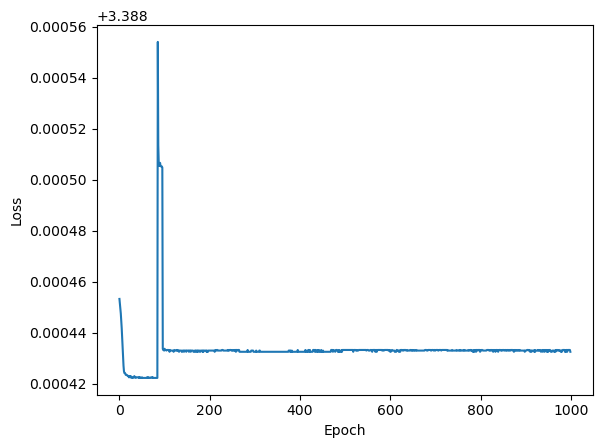

In [10]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

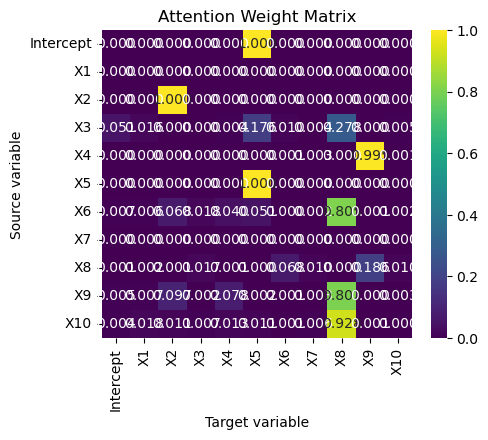

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
# 轉成 numpy
attn_matrix = final_attn.detach().numpy()

# 設定變數名稱
labels = cols

plt.figure(figsize=(5,4))

sns.heatmap(
    attn_matrix,
    annot=True,        # 顯示數值
    fmt=".3f",         # 小數三位
    xticklabels=labels,
    yticklabels=labels,
    cmap="viridis"
)

plt.xlabel("Target variable")
plt.ylabel("Source variable")
plt.title("Attention Weight Matrix")

plt.show()

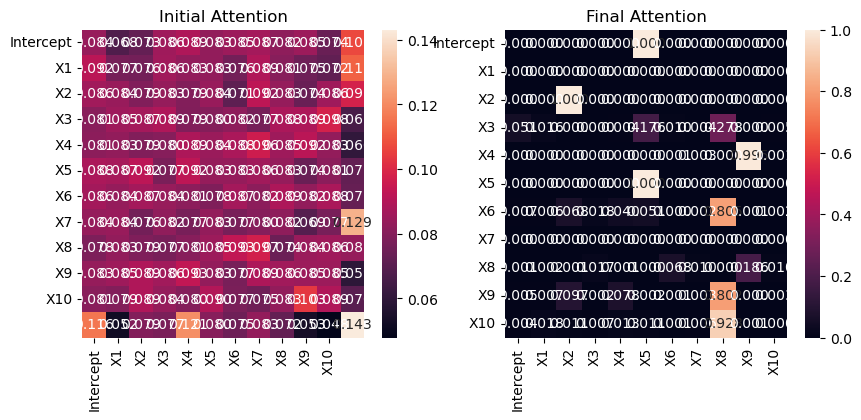

In [12]:
fig, axes = plt.subplots(1,2,figsize=(10,4))

sns.heatmap(
    initial_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_title("Initial Attention")


sns.heatmap(
    final_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_title("Final Attention")


plt.show()

In [13]:
beta_ols = result.params.values
beta_attn = beta.detach().numpy()
beta_attn = beta_attn.flatten()
beta_ridge = ridge.coef_

In [14]:
print(beta_ols)
print(beta_attn)
print(beta_ridge)

[ 1.93273834  1.98451346 -1.45954379  0.52287791 -0.13296797  3.01704152
  0.0043329  -0.04972681 -0.05909516 -0.03971386  0.01332317]
[ 1.9320313   1.9816216  -1.4583755   0.5228779  -0.13279112  3.014958
  0.00433289 -0.04972266 -0.05909821 -0.03971389  0.01332251]
[ 1.929794    1.98167384 -1.45727846  0.52268965 -0.13274348  3.01271197
  0.00440038 -0.04965092 -0.05933969 -0.03950972  0.01337453]


In [15]:
X_val = validation[cols].values
y_val = validation["Y"].values

y_pred_ols = X_val @ beta_ols

y_pred_attn = X_val @ beta_attn

y_pred_ridge = X_val @ beta_ridge

In [16]:
from sklearn.metrics import mean_squared_error

mse_ols = mean_squared_error(
    y_val,
    y_pred_ols
)

mse_attn = mean_squared_error(
    y_val,
    y_pred_attn
)

mse_ridge = mean_squared_error(
    y_val,
    y_pred_ridge
)

print(f"OLS MSE = {mse_ols:.6f}")
print(f"Attention MSE = {mse_attn:.6f}")
print(f"Ridge MSE = {mse_ridge:.6f}")

OLS MSE = 3.850518
Attention MSE = 3.849754
Ridge MSE = 3.850267


In [17]:
rmse_ols = np.sqrt(mse_ols)
rmse_attn = np.sqrt(mse_attn)
rmse_ridge = np.sqrt(mse_ridge)

print(f"OLS RMSE = {rmse_ols:.6f}")
print(f"Attention RMSE = {rmse_attn:.6f}")
print(f"Ridge RMSE = {rmse_ridge:.6f}")

OLS RMSE = 1.962274
Attention RMSE = 1.962079
Ridge RMSE = 1.962210


In [18]:
from sklearn.metrics import r2_score

ols_r2 = r2_score(y_val, y_pred_ols)
attn_r2 = r2_score(y_val, y_pred_attn)
ridge_r2 = r2_score(y_val, y_pred_ridge)

print(f"OLS R² = {ols_r2:.6f}")
print(f"Attention R² = {attn_r2:.6f}")
print(f"Ridge R² = {ridge_r2:.6f}")

OLS R² = 0.796702
Attention R² = 0.796742
Ridge R² = 0.796715


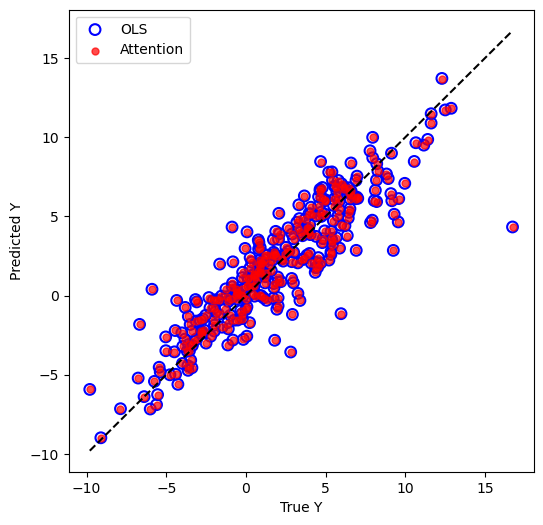

In [19]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_val,
    y_pred_ols,
    facecolors="none",
    edgecolors="blue",
    s=60,
    linewidth=1.5,
    label="OLS"
)

plt.scatter(
    y_val,
    y_pred_attn,
    color="red",
    s=25,
    alpha=0.7,
    label="Attention"
)

low = min(y_val.min(), y_pred_ols.min(), y_pred_attn.min())
high = max(y_val.max(), y_pred_ols.max(), y_pred_attn.max())

plt.plot([low, high], [low, high], "k--")

plt.xlabel("True Y")
plt.ylabel("Predicted Y")
plt.legend()
plt.show()

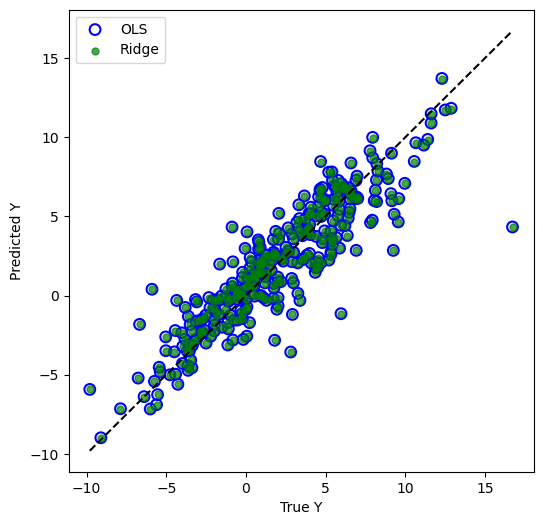

In [20]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_val,
    y_pred_ols,
    facecolors="none",
    edgecolors="blue",
    s=60,
    linewidth=1.5,
    label="OLS"
)

plt.scatter(
    y_val,
    y_pred_ridge,
    color="green",
    s=25,
    alpha=0.7,
    label="Ridge"
)

low = min(y_val.min(), y_pred_ols.min(), y_pred_ridge.min())
high = max(y_val.max(), y_pred_ols.max(), y_pred_ridge.max())

plt.plot([low, high], [low, high], "k--")

plt.xlabel("True Y")
plt.ylabel("Predicted Y")
plt.legend()
plt.show()

In [21]:
true_beta = pd.read_csv(
    r"C:\Users\GUO\Desktop\Attention_NN_CYG_SSE\產生模擬資料\true_beta.csv"
)

beta_true = true_beta["True_Coefficient"].values

print(beta_true)

[ 1.   2.  -1.5  0.5  0.   3.   0.   0.   0.   0.   0. ]


In [22]:
ols_bias = abs(beta_ols - beta_true)
attn_bias = abs(beta_attn - beta_true)
ridge_bias = abs(beta_ridge - beta_true)

print(ols_bias.sum())
print(attn_bias.sum())
print(ridge_bias.sum())

1.3277603777971425
1.3288512523286045
1.3252620270240387


In [23]:
print(XTX)
attn_table = pd.DataFrame(final_attn,index = cols, columns = cols)
print(attn_table)

            Intercept          X1          X2          X3          X4  \
Intercept  700.000000   -6.770654   26.077024   21.763461   -4.691188   
X1          -6.770654  674.920381   25.724427   13.663655   -2.975140   
X2          26.077024   25.724427  694.313341  -53.488038   14.160446   
X3          21.763461   13.663655  -53.488038  659.797241    8.603685   
X4          -4.691188   -2.975140   14.160446    8.603685  670.059749   
X5         -10.094301   30.739848   -3.922648   40.357047   16.163796   
X6          53.093997   -7.770265   27.700151  -42.237083    8.712044   
X7          30.854726  -17.670628   37.356076  -16.812509  -56.664918   
X8         -20.491921   21.737582   26.643042  -11.149045   -5.031325   
X9          13.770219    2.647245   32.962421   -0.080183   15.691337   
X10         12.456642   -7.674679  -17.266176   -4.268836  -22.114637   

                   X5          X6          X7          X8          X9  \
Intercept  -10.094301   53.093997   30.854726  -20

In [24]:
Adaptive = adaptive.detach().numpy()
Adaptive = pd.DataFrame(Adaptive,index = cols, columns = cols)

print(Adaptive)

              Intercept            X1            X2            X3  \
Intercept  2.000028e+00  7.079247e-07  2.977873e-09  3.461716e-06   
X1         1.475675e-28  2.000028e+00  4.967023e-39  1.069200e-28   
X2         9.410625e-13  2.176951e-12  3.000028e+00  1.950040e-12   
X3         5.128618e-02  1.639056e-02  2.497792e-05  2.000042e+00   
X4         4.683266e-05  3.229772e-05  3.208247e-05  2.009107e-04   
X5         6.149575e-07  1.015875e-07  8.178441e-10  6.988277e-08   
X6         7.252958e-03  6.301732e-03  6.808671e-02  1.837255e-02   
X7         1.049602e-10  2.841606e-10  3.486966e-13  2.421065e-10   
X8         1.250586e-03  1.973669e-03  9.944040e-04  1.712383e-02   
X9         4.843549e-03  6.573041e-03  9.727484e-02  1.723947e-03   
X10        4.444869e-03  1.806858e-02  1.053010e-02  7.486131e-03   

                     X4            X5            X6            X7  \
Intercept  1.871790e-06  9.999815e-01  2.906165e-07  3.751649e-06   
X1         1.080944e-30  9.910062

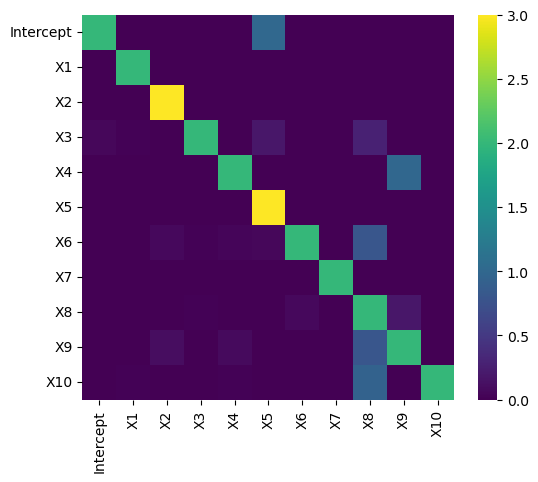

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(
    adaptive,
    xticklabels=cols,
    yticklabels=cols,
    cmap="viridis"
)
plt.show()